### 1. PROBLEM STATEMENT

The goal of this project is to build a machine learning model that can detect fraudulent banking transactions based on customer behavior, transaction patterns, and risk indicators.

### 2. LOAD LIBRARIES AND DATA

In [47]:
import warnings
import itertools
import random

#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

In [48]:
fraud=pd.read_csv("FraudShield_Banking_Data.csv")
fraud.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [49]:
fraud.shape

(50000, 25)

In [8]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  str    
 4   Transaction_Date                       49997 non-null  str    
 5   Transaction_Type                       49996 non-null  str    
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  str    
 8   Transaction_Location                   49994 non-null  str    
 9   Customer_Home_Location                 49996 non-null  str    
 10  Distance_From_Home                     49998 non-null  float64
 11  Device_ID    

In [58]:
#Removing irrelevant columns
#The ID'S columnS is are irrelevant.They are identifiers and carry no predictive meaning
fraud =fraud.drop(columns=[
"Transaction_ID",
"Customer_ID",
"Merchant_ID",
"Device_ID",
"IP_Address"
])

### Cleaning Target Variable

In [59]:
fraud.isnull().sum().sort_values(ascending=False)

Failed_Transaction_Count                 11
Transaction_Amount (in Million)           9
Merchant_Category                         9
Transaction_Time                          9
Avg_Transaction_Amount (in Million)       9
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Transaction_Location                      6
Weekly_Transaction_Count                  5
Is_New_Merchant                           5
Is_International_Transaction              4
Transaction_Type                          4
Customer_Home_Location                    4
Max_Transaction_Last_24h (in Million)     4
Transaction_Date                          3
Card_Type                                 3
Previous_Fraud_Count                      3
Unusual_Time_Transaction                  3
Distance_From_Home                        2
Fraud_Label                               0
dtype: int64

In [60]:
fraud.dropna(subset=['Fraud_Label'], inplace=True)

# Convert target to numeric
y = fraud['Fraud_Label'].map({'Fraud': 1, 'Normal': 0})
X = fraud.drop('Fraud_Label', axis=1)

OUTLIERS

In [61]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_19076\197916445.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


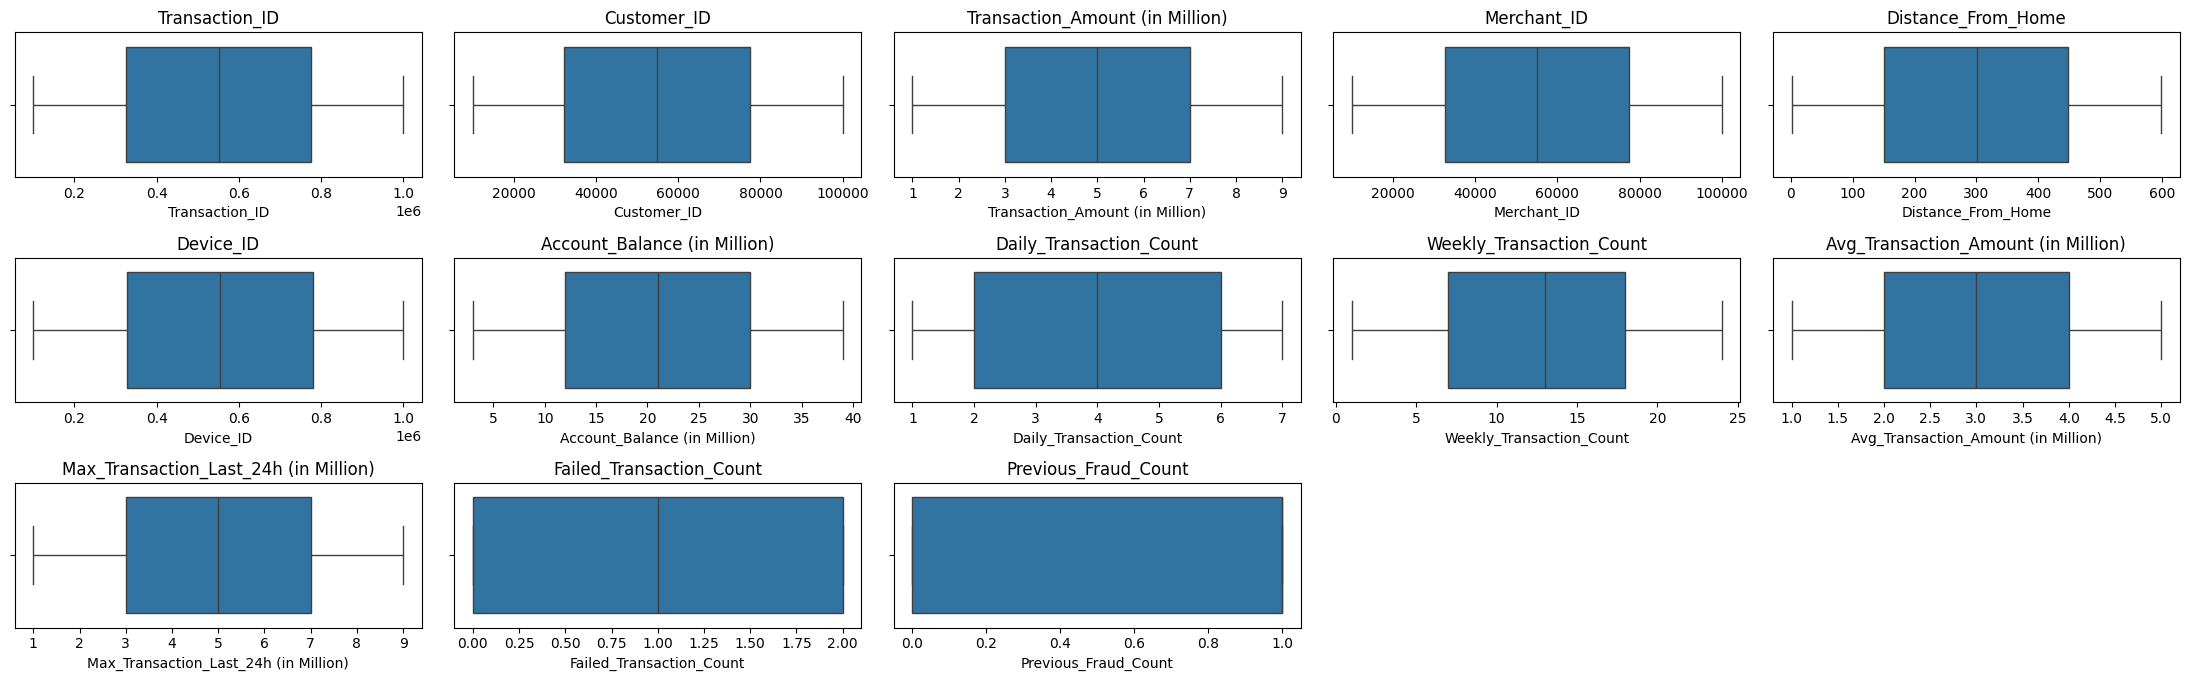

In [52]:
fig = plt.figure(figsize=(22,20))

for i in range(len(num_cols)):
    ax = fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=X[num_cols].iloc[:, i], ax=ax)
    ax.set_title(num_cols[i])

plt.tight_layout()
plt.show()

The dataset shows no outliers and this strongly suggests the dataset is synthetic or pre-cleaned because in In real financial datasets, we normally see Large transaction outliers,extremely skewed spending behavior, heavy-tailed distributions.

In [53]:
fig = plt.figure(figsize=(20,18))
for i in range(len(cat_cols.columns)):
    fig.add_subplot(7, 5, i+1)
    sns.countplot(x=X[cat_cols].iloc[:, i],ax=ax)
plt.tight_layout()
plt.show()

AttributeError: 'Index' object has no attribute 'columns'

<Figure size 2000x1800 with 0 Axes>

### TRAIN-TEST SPLIT

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### EDA ON TRAINING DATASET

In [63]:
X_train.isnull().sum().sort_values(ascending=False)

Transaction_Time                         9
Failed_Transaction_Count                 9
Daily_Transaction_Count                  9
Avg_Transaction_Amount (in Million)      8
Transaction_Amount (in Million)          7
Account_Balance (in Million)             7
Merchant_Category                        7
Weekly_Transaction_Count                 5
Is_New_Merchant                          5
Transaction_Location                     5
Is_International_Transaction             4
Transaction_Type                         4
Max_Transaction_Last_24h (in Million)    4
Customer_Home_Location                   4
Transaction_Date                         3
Unusual_Time_Transaction                 3
Card_Type                                3
Distance_From_Home                       2
Previous_Fraud_Count                     2
dtype: int64

In [64]:
#percentage missingness
missing=X.isnull().sum()
percentage=(missing/len(X))*100

missing_table=pd.DataFrame({
    "Missing":missing,
    "Percentage":percentage
})

missing_table=missing_table[missing_table["Missing"]>0]
missing_table.sort_values('Percentage',ascending=False)

,Missing,Percentage
Failed_Transaction_Count,11,0.022002
Transaction_Time,9,0.018001
Transaction_Amount (in Million),9,0.018001
Avg_Transaction_Amount (in Million),9,0.018001
Merchant_Category,9,0.018001
Account_Balance (in Million),9,0.018001
Daily_Transaction_Count,9,0.018001
Transaction_Location,6,0.012001
Weekly_Transaction_Count,5,0.010001
Is_New_Merchant,5,0.010001


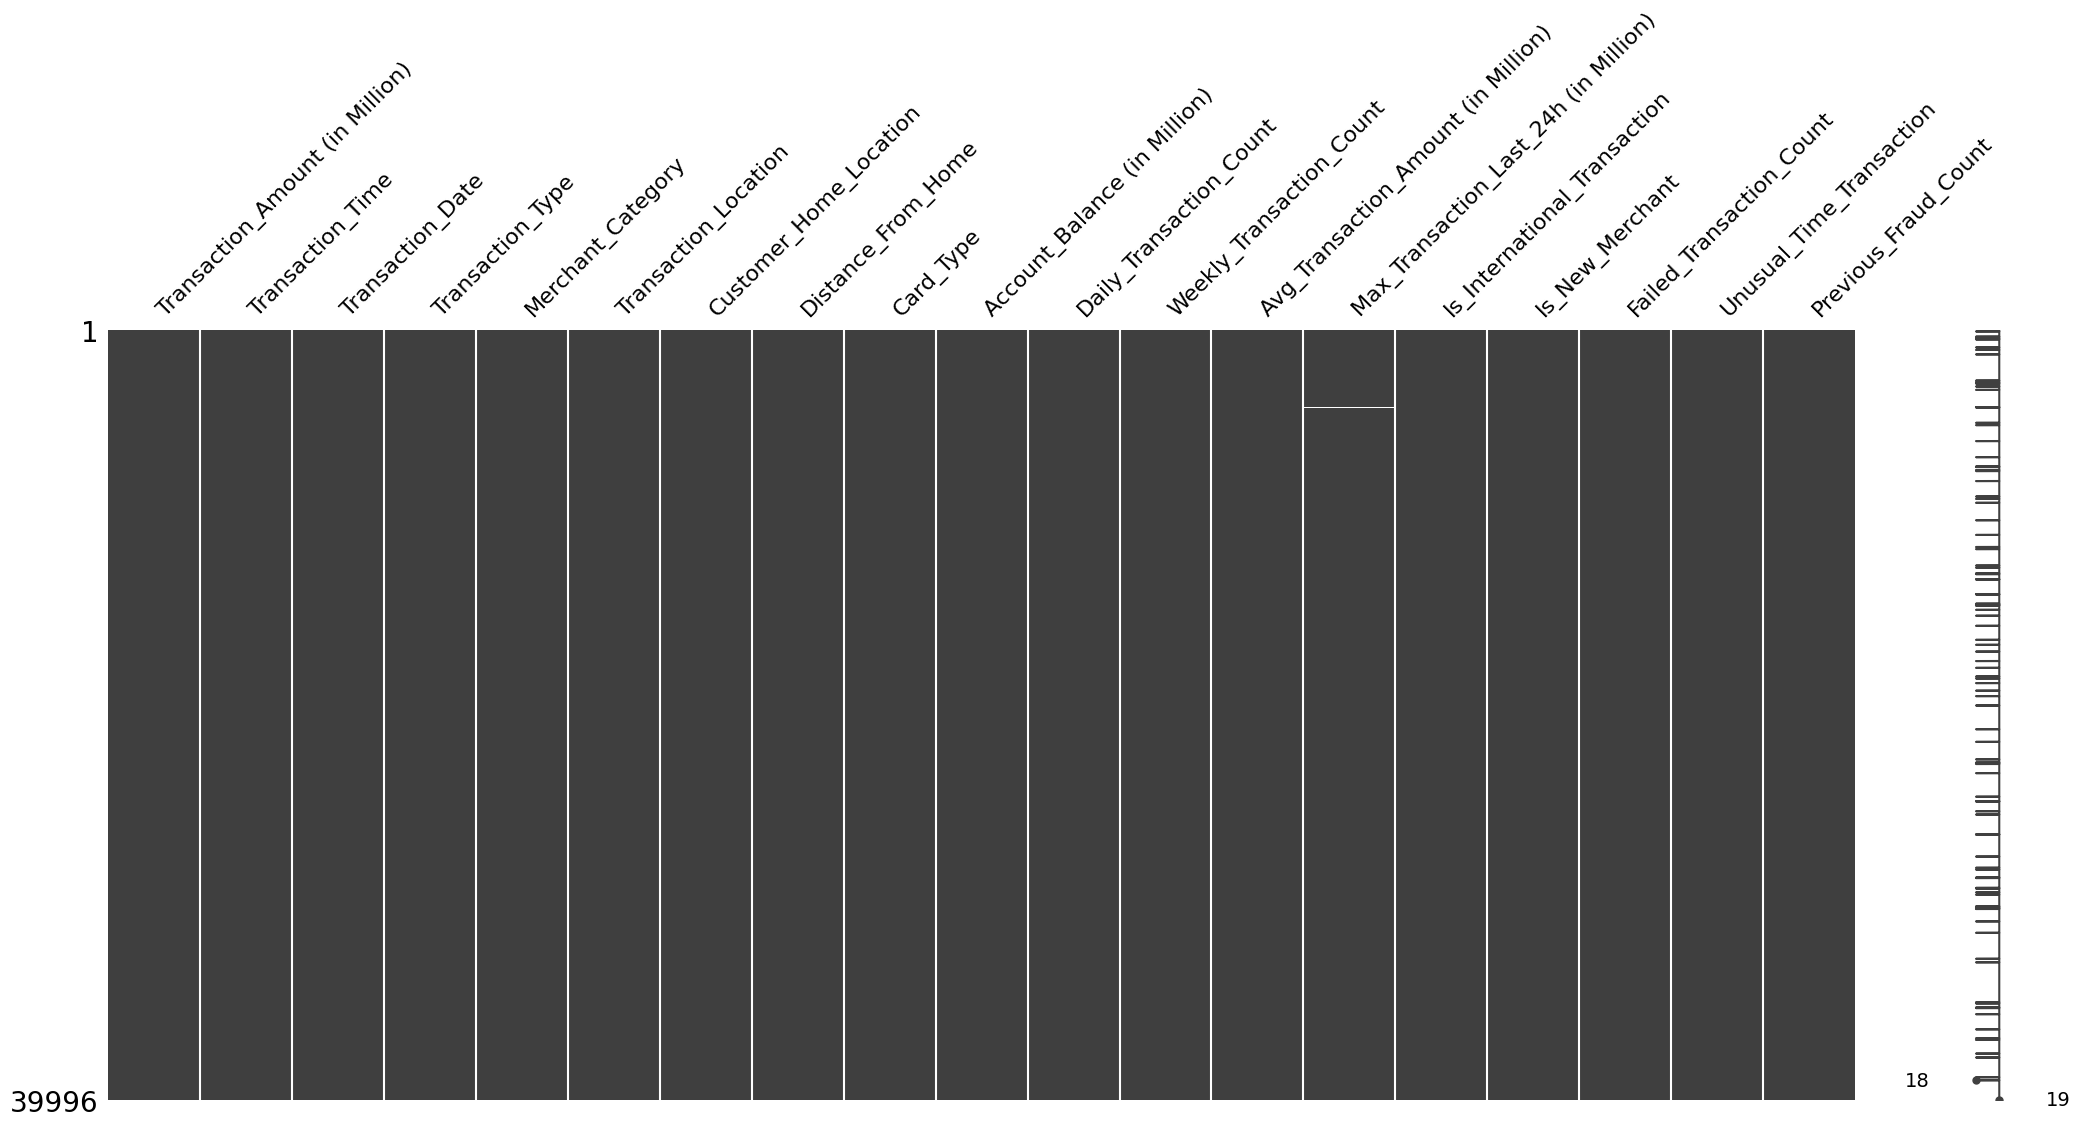

In [65]:
# Missing values
X_train.isnull().sum().sort_values(ascending=False)

mn.matrix(X_train)
plt.show()

### FEATURE ENGINEERING

In [66]:
def feature_engineering(df):
    df = df.copy()
    
    # Convert time
    df["Transaction_Time"] = pd.to_datetime(df["Transaction_Time"])
    df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])
    
    # Time features
    df["Transaction_Hour"] = df["Transaction_Time"].dt.hour
    df["Transaction_Day"] = df["Transaction_Date"].dt.dayofweek
    df["Transaction_Month"] = df["Transaction_Date"].dt.month
    
    # Night transactions
    df["Night_Transaction"] = df["Transaction_Hour"].apply(
        lambda x: 1 if x >= 22 or x <= 5 else 0
    )
    
    # Drop original
    df.drop(columns=["Transaction_Time", "Transaction_Date"], inplace=True)
    
    # Behavioral features
    df["Transaction_Deviation"] = (
        df["Transaction_Amount (in Million)"] /
        df["Avg_Transaction_Amount (in Million)"]
    )
    
    df["Transaction_Velocity"] = (
        df["Daily_Transaction_Count"] /
        df["Weekly_Transaction_Count"]
    )
    
    df["Transaction_Balance_Ratio"] = (
        df["Max_Transaction_Last_24h (in Million)"] /
        df["Account_Balance (in Million)"]
    )
    
    df["Distance_Risk"] = (df["Distance_From_Home"] > 200).astype(int)
    
    df["Fraud_History"] = (
        df["Previous_Fraud_Count"] +
        df["Failed_Transaction_Count"]
    )
    
    df["Log_Transaction_Amount"] = np.log1p(df["Transaction_Amount (in Million)"])
    
    df["Amount_to_Balance"] = (
        df["Transaction_Amount (in Million)"] /
        (df["Account_Balance (in Million)"] + 1)
    )
    
    df["Txn_per_hour"] = df["Daily_Transaction_Count"] / 24
    
    df["High_Risk_Combo"] = (
        (df["Night_Transaction"] == 1) &
        (df["Distance_Risk"] == 1)
    ).astype(int)
    
    return df

# Apply
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

C:\Users\mburu\AppData\Local\Temp\ipykernel_19076\1474868573.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Transaction_Time"] = pd.to_datetime(df["Transaction_Time"])
C:\Users\mburu\AppData\Local\Temp\ipykernel_19076\1474868573.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Transaction_Time"] = pd.to_datetime(df["Transaction_Time"])


### PREPROCESSING

In [67]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=np.number).columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_19076\774227395.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


Imputation (ONLY FIT ON TRAIN)

In [68]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Encoding

In [69]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = ohe.fit_transform(X_train[cat_cols])
encoded_test = ohe.transform(X_test[cat_cols])

encoded_train = pd.DataFrame(encoded_train, columns=ohe.get_feature_names_out(cat_cols))
encoded_test = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(cat_cols))

In [70]:
#Combine
X_train = pd.concat([X_train[num_cols].reset_index(drop=True), encoded_train], axis=1)
X_test = pd.concat([X_test[num_cols].reset_index(drop=True), encoded_test], axis=1)

Scaling

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### CORRELATION

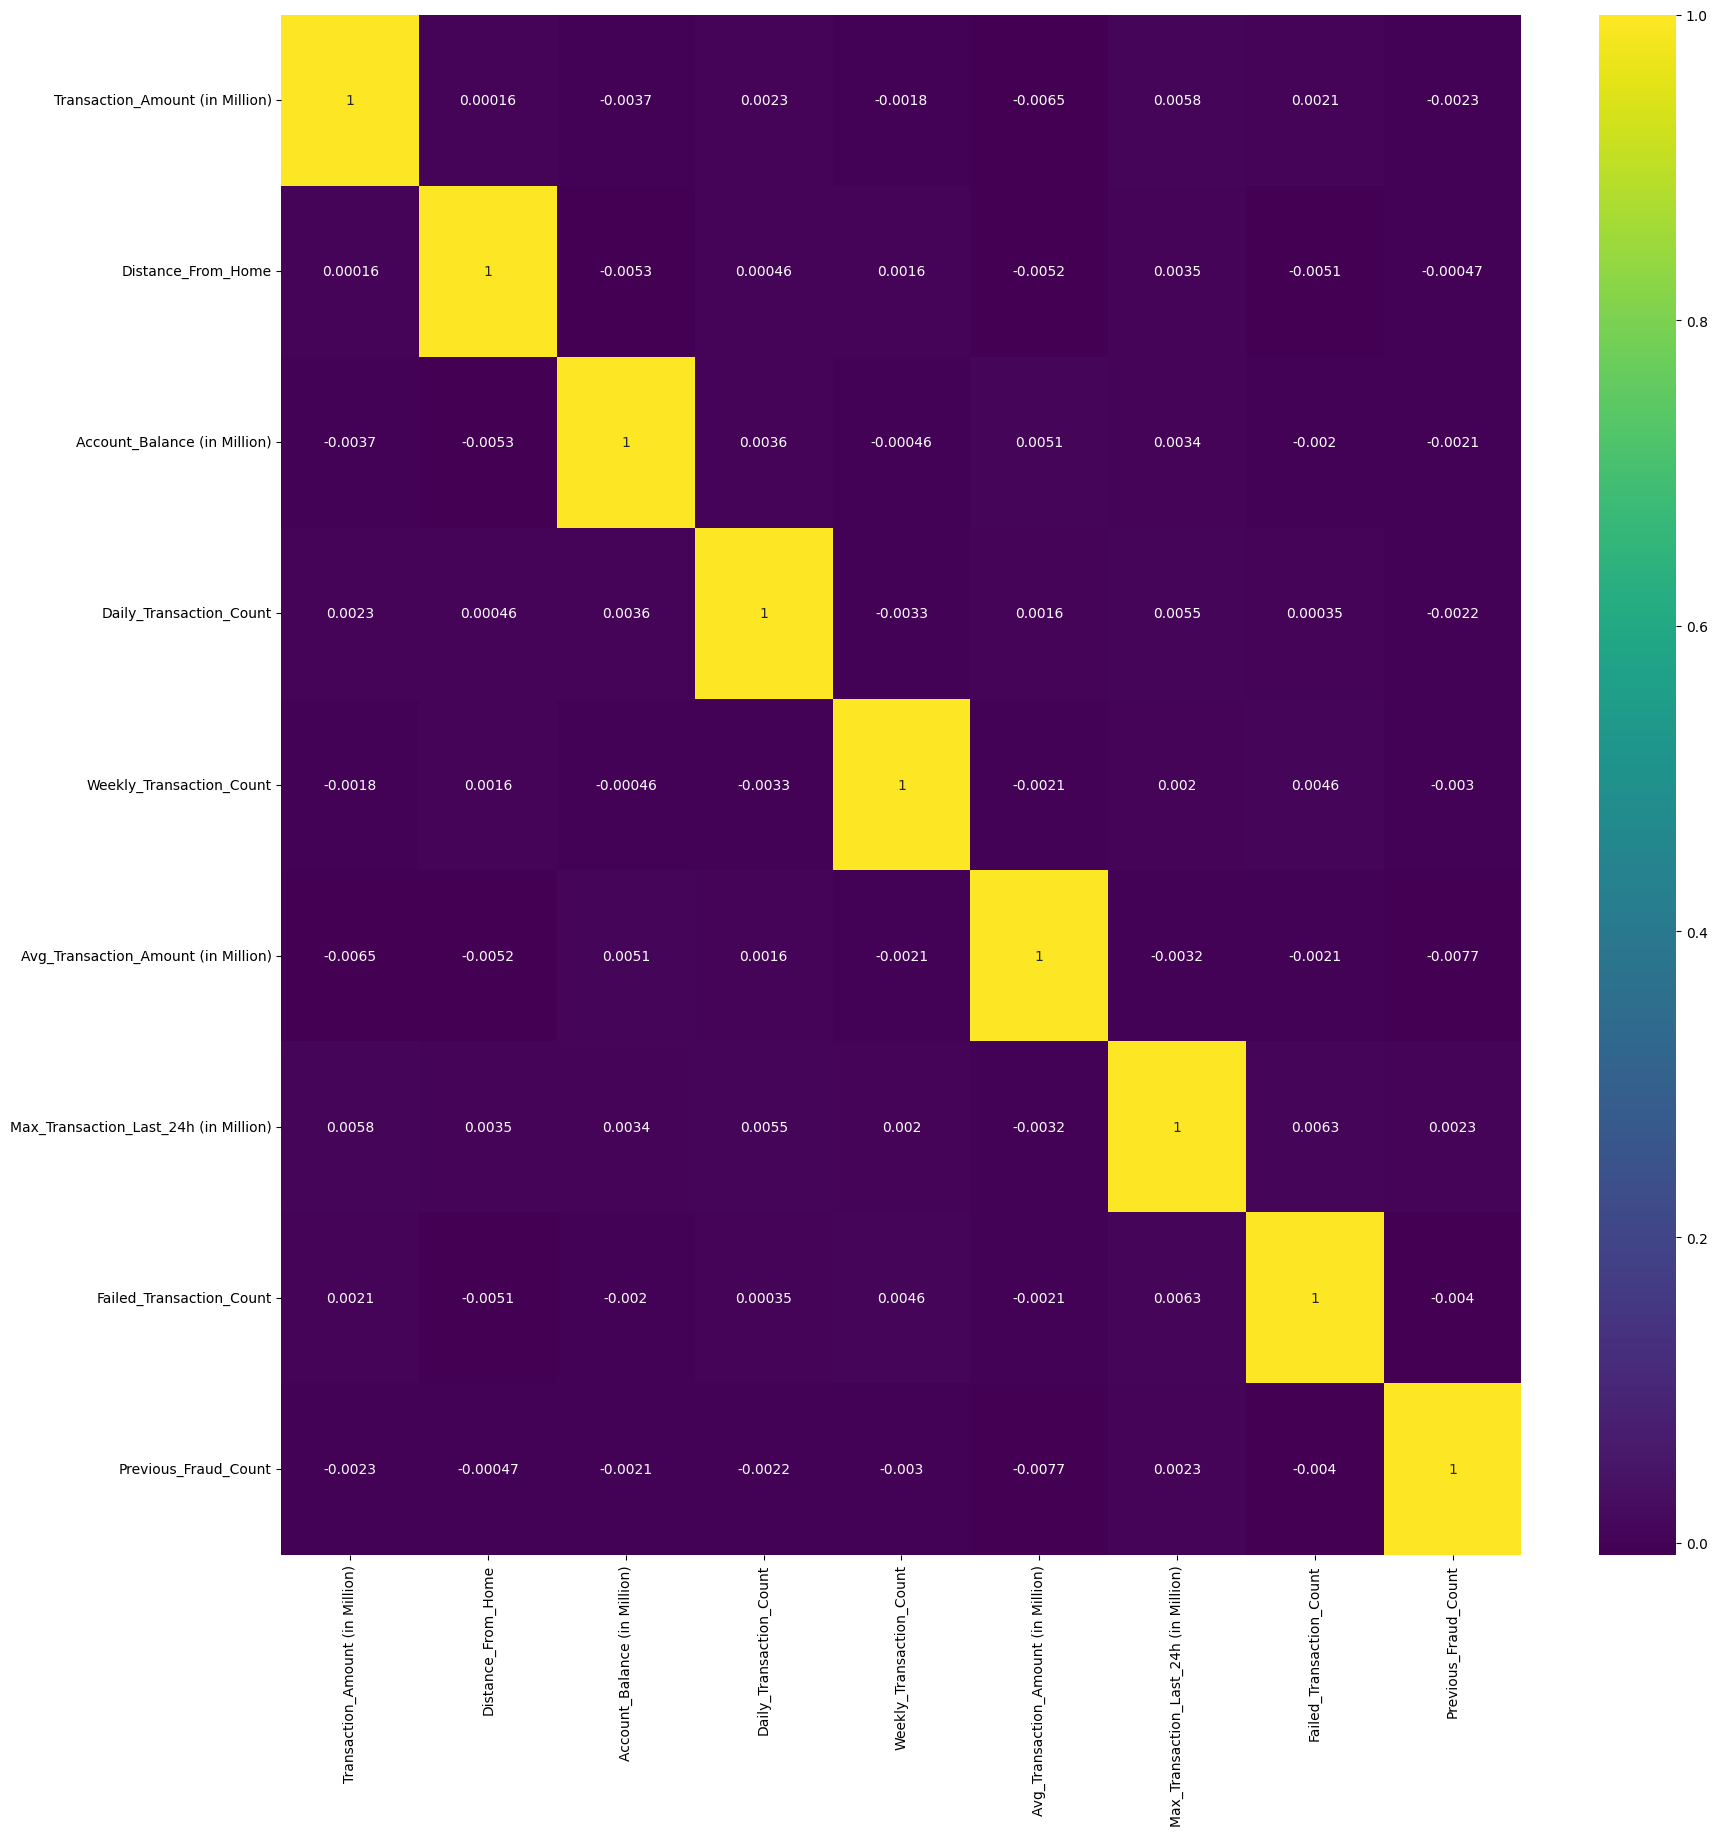

In [35]:
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

### HANDLE IMBALANCE

C:\Users\mburu\AppData\Local\Temp\ipykernel_19076\948335681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


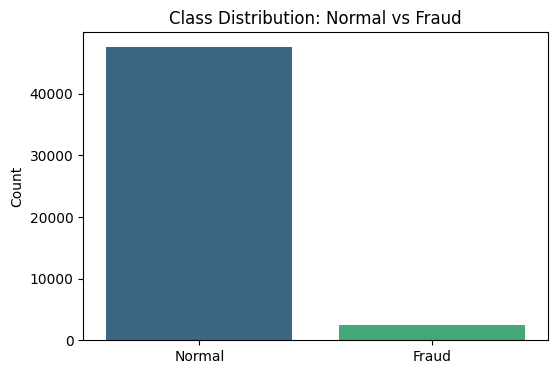

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(x=y, palette="viridis")

plt.xticks([0,1], ["Normal", "Fraud"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class Distribution: Normal vs Fraud")

plt.show()

In [73]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

### MODEL BUILDING

Random Forest 

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score , make_scorer


rf = RandomForestClassifier(n_estimators=50, random_state=42) 
f2_scorer = make_scorer(fbeta_score, beta=2)
scores = cross_val_score(
    rf,            
    X_res,       
    y_res.values.ravel(),        
    cv=5,         
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.79005586 0.99936923 0.99978977 0.99947444 1.        ]
Mean Fbeta score: 0.9577378611873992


logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression

lrc=LogisticRegression(random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    lrc,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.59823214 0.6350304  0.62622463 0.62136533 0.62995422]
Mean Fbeta score: 0.6221613419378463


AdaBoostClassifier

In [76]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    ada,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.75553097 0.96972501 0.96697678 0.96877882 0.96721311]
Mean Fbeta score: 0.9256449398814028


XG BOOST

In [77]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,eval_metric='logloss'
)

f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    xgb,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.78270866 0.99957951 0.99905378 0.99926418 0.99947444]
Mean Fbeta score: 0.9560161160102331


### MODEL EVALUATION

#### Selecting the best performing candidate model
When it comes to choosing the best candidate model in classification tasks, it is not enough to rely on one single metric like recall, precision etc...(But please note, the choice in evaluation metric should align with the business case). For classification, we take it a step further and look at the model performance per class- in this case, I want a model that is really good at identifying fraudsters- this is the actual business value of the ML model.

So we print the classification report of each model and see how good they are at minimizing false negative and then use the ROC-AUC curve to choose the best performing model.

In [78]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000



c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.60      0.74      9515
           1       0.06      0.52      0.11       485

    accuracy                           0.59     10000
   macro avg       0.51      0.56      0.42     10000
weighted avg       0.92      0.59      0.71     10000


AdaBoost
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      9515
           1       0.07      0.17      0.10       485

    accuracy                           0.84     10000
   macro avg       0.51      0.52      0.51     10000
weighted avg       0.91      0.84      0.88     10000


XGBoost
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95 

ROC CURVE

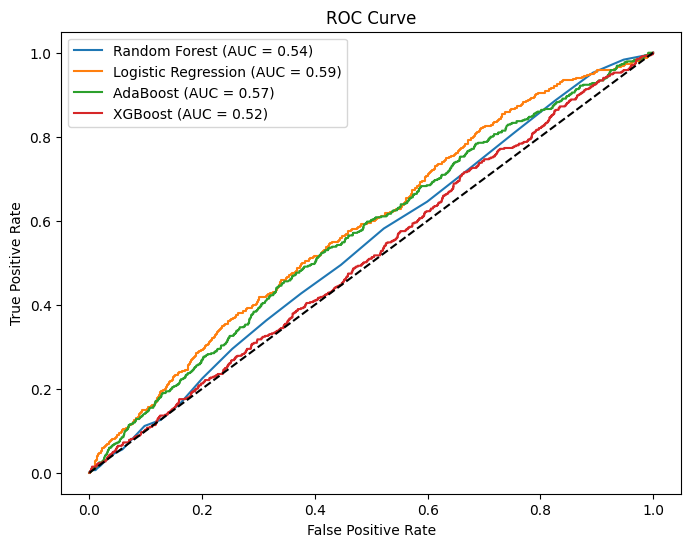

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

We choose XGBoost even when it doesn't have the highest Area Under the Curve (AUC) because of its reliability in production, handling of missing data, and ability to prevent overfitting through strong regularization.

### HYPERPARAMETER TUNING (XGBOOST)

In [82]:
xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 200,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_res, y_res)

best_model = grid.best_estimator_

### FINAL EVALUATION

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000

AUC: 0.5422231853123933


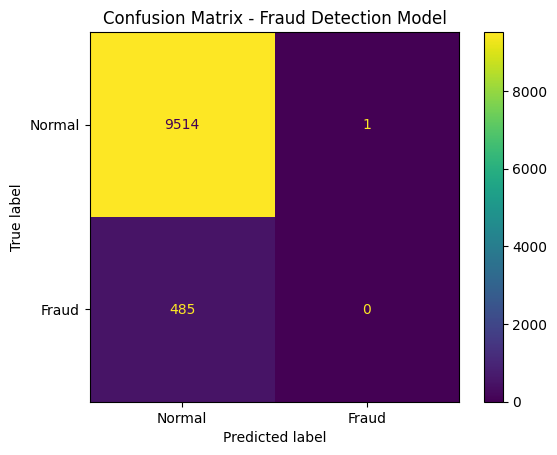

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))

# AUC
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()

### SAVE MODEL

In [85]:
import pickle

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)